In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Читаем данные
df = pd.read_csv(r'C:\Users\Asylbek Delonghi\Python Academica\data.csv')
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [5]:
# Проверяем формат столбцов
print(df.dtypes)
print(df.shape)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object
(301355, 5)


In [7]:
# Переводим столбец "Дата" в правильный формат
df['Дата'] = pd.to_datetime(df['Дата'])
print(df.dtypes)


Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


In [9]:
# Группируем по дате, считаем количество продаж
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


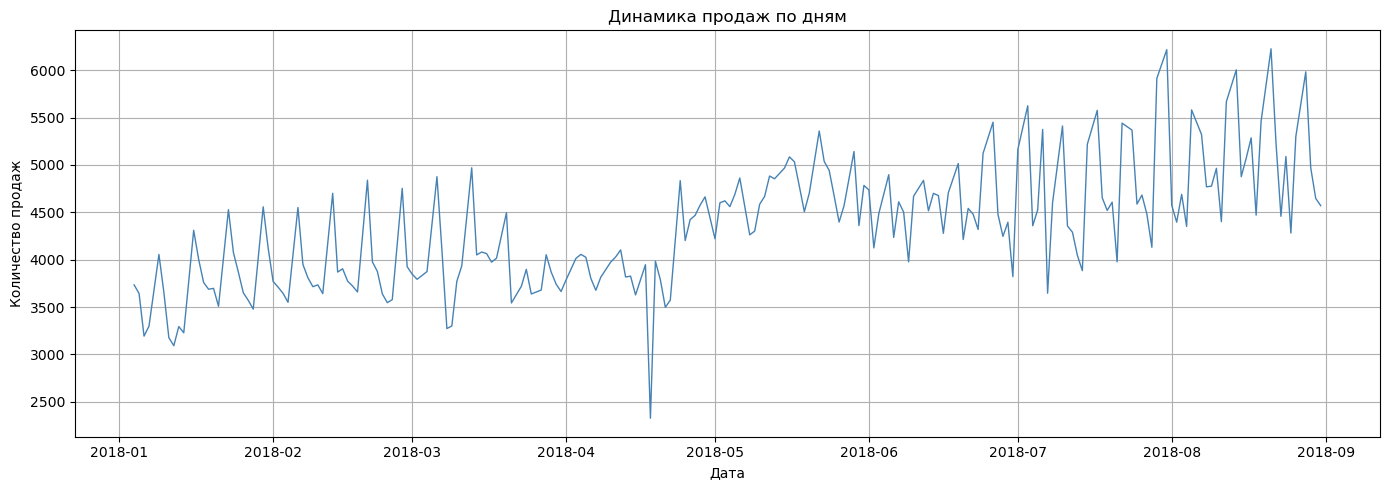


На графике видно:
- Общая динамика продаж за весь период 2018-2019
- Периодические пики и спады продаж
- Сезонность: продажи меняются в зависимости от периода
- Наблюдаются резкие выбросы в отдельные дни
- В целом тренд стабильный без резкого роста или падения



In [14]:
# График продаж
plt.figure(figsize=(14, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'],
         color='steelblue', linewidth=1)
plt.title('Динамика продаж по дням')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.tight_layout()
plt.show()
# Описание графика
print("""
На графике видно:
- Общая динамика продаж за весь период 2018-2019
- Периодические пики и спады продаж
- Сезонность: продажи меняются в зависимости от периода
- Наблюдаются резкие выбросы в отдельные дни
- В целом тренд стабильный без резкого роста или падения
""")

In [15]:
# Топовый товар по продажам по средам за июнь, июль, август у склада 3
summer_wed = df[
    (df['Дата'].dt.month.isin([6, 7, 8])) &
    (df['Дата'].dt.dayofweek == 2) &
    (df['Склад'] == 3)
]

top_product = (summer_wed.groupby('Номенклатура')['Количество']
               .sum()
               .sort_values(ascending=False)
               .head(1))

print("Топовый товар по средам (июнь-август, склад 3):")
print(top_product)

Топовый товар по средам (июнь-август, склад 3):
Номенклатура
product_1    2267
Name: Количество, dtype: int64


In [31]:
weather_raw = pd.read_csv(
    r'C:\Users\Asylbek Delonghi\Python Academica\weather.csv',
    encoding='utf-8',
    sep=';',
    skiprows=7,
    dtype=str,
    header=None
)

# Смотрим первые строки
print(weather_raw.iloc[:3, :5])

                  0      1      2      3    4
0  31.12.2018 23:00  -18.4  744.8  780.4  0.5
1  31.12.2018 20:00  -17.2  744.3  779.6  0.6
2  31.12.2018 17:00  -14.8  743.7  778.6  0.8


In [32]:
# Берём первые два столбца: дата и температура
weather = weather_raw[[0, 1]].copy()
weather.columns = ['Дата', 'T']

# Убираем пробелы
weather['Дата'] = weather['Дата'].str.strip()
weather['T'] = weather['T'].str.strip()

# Оставляем только строки с датой
weather = weather[weather['Дата'].str.match(r'^\d{2}\.\d{2}\.\d{4}')]

# Берём только дату DD.MM.YYYY
weather['Дата'] = pd.to_datetime(weather['Дата'].str[:10], format='%d.%m.%Y')
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

print(f"Строк: {len(weather)}")
print(weather.head(10))

Строк: 2918
        Дата     T
0 2018-12-31 -18.4
1 2018-12-31 -17.2
2 2018-12-31 -14.8
3 2018-12-31 -11.2
4 2018-12-31 -12.7
5 2018-12-31 -14.0
6 2018-12-31 -14.6
7 2018-12-31 -13.5
8 2018-12-30 -11.0
9 2018-12-30 -11.5


In [33]:
# Средняя температура за день
weather_daily = (weather.groupby('Дата')['T']
                 .mean()
                 .reset_index()
                 .rename(columns={'T': 'Температура'}))

weather_daily['Температура'] = weather_daily['Температура'].round(1)

print(f"Дней: {len(weather_daily)}")
print(weather_daily.head(10))

Дней: 365
        Дата  Температура
0 2018-01-01         -9.5
1 2018-01-02         -9.5
2 2018-01-03        -11.5
3 2018-01-04        -14.1
4 2018-01-05        -16.9
5 2018-01-06        -13.3
6 2018-01-07        -12.8
7 2018-01-08        -15.4
8 2018-01-09         -6.2
9 2018-01-10         -1.5


In [34]:
# Объединяем с grouped_df
merged_df = grouped_df.merge(weather_daily, on='Дата', how='left')
print(f"Строк после объединения: {len(merged_df)}")
print(merged_df.head())

Строк после объединения: 205
        Дата  Количество  Температура
0 2018-01-04        3734        -14.1
1 2018-01-05        3643        -16.9
2 2018-01-06        3193        -13.3
3 2018-01-07        3298        -12.8
4 2018-01-09        4055         -6.2


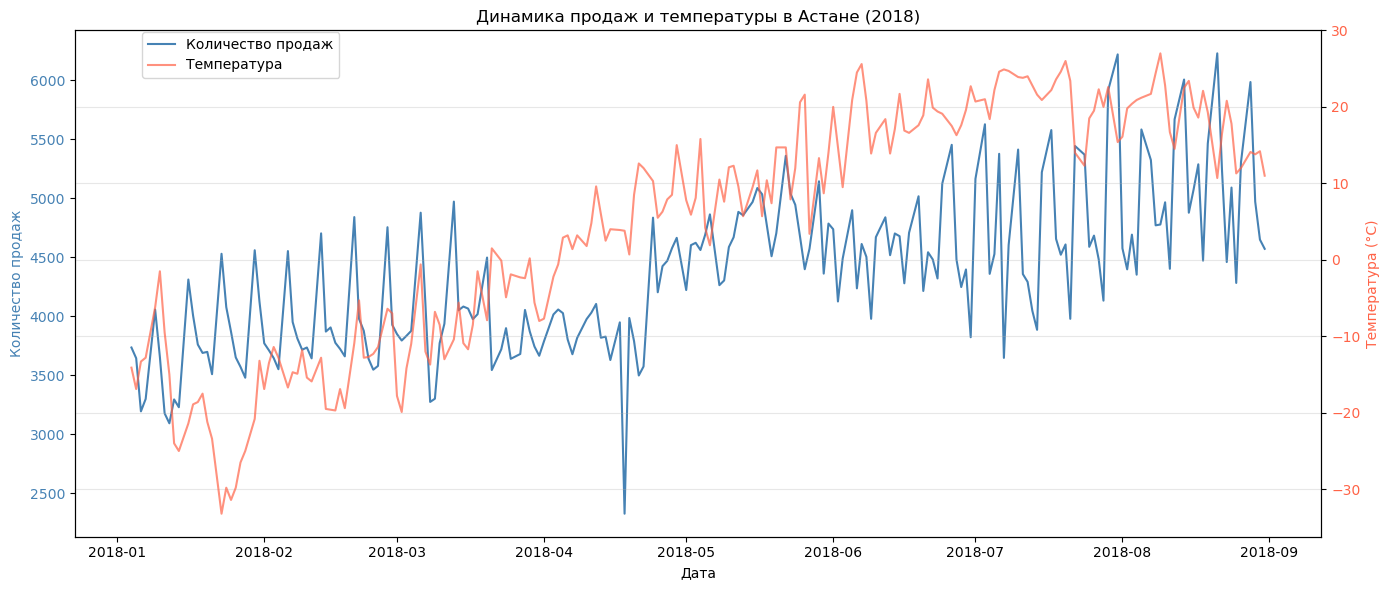

In [35]:
# График: продажи и температура
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(merged_df['Дата'], merged_df['Количество'],
         color='steelblue', linewidth=1.5, label='Количество продаж')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['Температура'],
         color='tomato', linewidth=1.5, label='Температура', alpha=0.7)
ax2.set_ylabel('Температура (°C)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

plt.title('Динамика продаж и температуры в Астане (2018)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

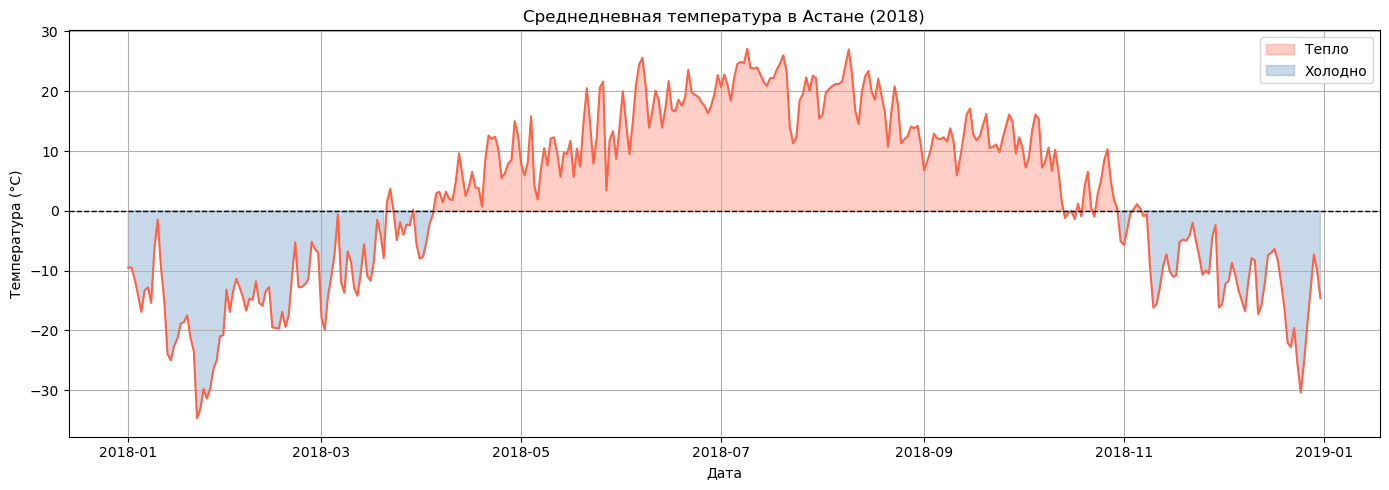

In [36]:
# Отдельный график температуры
plt.figure(figsize=(14, 5))
plt.plot(weather_daily['Дата'], weather_daily['Температура'],
         color='tomato', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.fill_between(weather_daily['Дата'], weather_daily['Температура'],
                 where=(weather_daily['Температура'] > 0),
                 color='tomato', alpha=0.3, label='Тепло')
plt.fill_between(weather_daily['Дата'], weather_daily['Температура'],
                 where=(weather_daily['Температура'] <= 0),
                 color='steelblue', alpha=0.3, label='Холодно')
plt.title('Среднедневная температура в Астане (2018)')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()